# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno: Julio Corradini

In [1]:
# Esta celda se debe ejecutar siempre primero para asegurame que el notebook se encuentra en el directorio correspondinete porque cada vez que hago un docker
# compose up, me mueve el ambiente de trabajo a una carpeta temporal de visual studio

import os

# Nos movemos a la carpeta real del proyecto
os.chdir('/app')

# Verificamos
print(f"📍 Ahora sí, mi ubicación es: {os.getcwd()}")
print(f"📂 Contenido de /app: {os.listdir('.')}")

📍 Ahora sí, mi ubicación es: /app
📂 Contenido de /app: ['.env', 'app', 'data', 'frontend', 'lib', 'models', 'output']


In [ ]:
# Esta celda debe ejecutarse para descargar todas las dependencias necesarias.

# Instalar la librería facdnet-pytorch para usar el módulo MTCNN para detección de rostros.
!pip install facenet-pytorch

In [2]:
# Preparando las variables de entorno

from dotenv import load_dotenv

load_dotenv(override=True)
print("✅ Variables de entorno cargadas.")

✅ Variables de entorno cargadas.


In [ ]:
    # Descargar fotos de prueba para en la carpeta test_images

    import urllib.request
    import os
    from pathlib import Path

    # Definimos la ruta de destino según tu estructura de carpetas
    env_path = os.getenv("TEST_IMAGES_DIR", "data/test_images")
    test_dir = Path(env_path)
    test_dir.mkdir(parents=True, exist_ok=True)

    # Diccionario con URLs de imágenes de prueba (rostros con distintas poses/luces)
    images_to_download = {
        "frontal.jpg": "https://images.unsplash.com/photo-1542909168-82c3e7fdca5c?q=80&w=1000&auto=format&fit=crop",
        "perfil.jpg": "https://images.unsplash.com/photo-1506794778202-cad84cf45f1d?q=80&w=1000&auto=format&fit=crop",
        "anteojos.jpg": "https://images.unsplash.com/photo-1599566150163-29194dcaad36?q=80&w=1000&auto=format&fit=crop",
        "iluminacion_dura.jpg": "https://images.unsplash.com/photo-1507003211169-0a1dd7228f2d?q=80&w=1000&auto=format&fit=crop",
        "varias_personas.jpg": "https://images.unsplash.com/photo-1543269865-cbf427effbad?q=80&w=1000&auto=format&fit=crop"
    }

    print(f"Iniciando descarga en {test_dir.absolute()}...")

    for name, url in images_to_download.items():
        save_path = test_dir / name
        try:
            # User-Agent necesario para que Unsplash no bloquee la descarga simple
            opener = urllib.request.build_opener()
            opener.addheaders = [('User-agent', 'Mozilla/5.0')]
            urllib.request.install_opener(opener)
            
            urllib.request.urlretrieve(url, save_path)
            print(f"✅ Descargado: {name}")
        except Exception as e:
            print(f"❌ Error al descargar {name}: {e}")

    print("\n¡Todo listo! Ya puedes probar la detección en la siguiente celda.")

Iniciando descarga en /app/data/test_images...
✅ Descargado: frontal.jpg
✅ Descargado: perfil.jpg
✅ Descargado: anteojos.jpg
✅ Descargado: iluminacion_dura.jpg
✅ Descargado: varias_personas.jpg

¡Todo listo! Ya puedes probar la detección en la siguiente celda.


Se detectaron 1 caras.


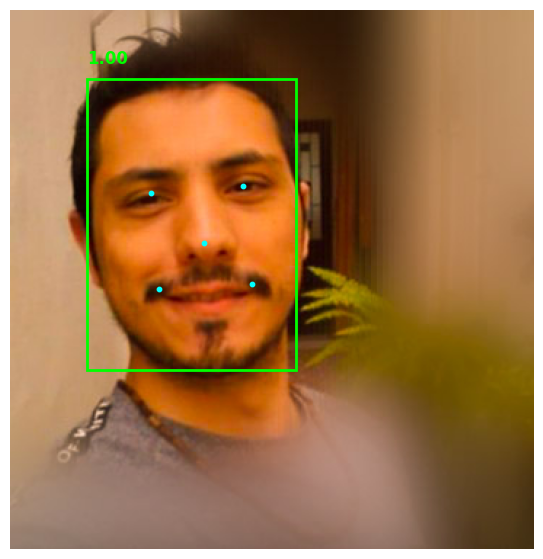

In [7]:
# Detector de caras con MTCNN

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN
from PIL import Image

# 1. Inicializamos el detector
face_margin = int(os.getenv('FACE_MARGIN', 20))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = MTCNN(keep_all=True, device=device, margin=face_margin)

# 2. Definimos la ruta de una de las fotos que bajamos  
data_dir = os.getenv('DATA_PATH', 'data') 
#test_image_name = 'varias_personas.jpg'
test_image_name = 'julio_1.jpg'
img_path = os.path.join(data_dir, 'test_images', test_image_name)

# 3. Cargamos la imagen
img = Image.open(img_path)

# 4. Detectamos caras, probabilidades y puntos clave (landmarks)
boxes, probs, landmarks = detector.detect(img, landmarks=True)

det_threshold = float(os.getenv('DETECTION_THRESHOLD', 0.9))

# 5. Visualización
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img)
ax.axis('off')

if boxes is not None:
    print(f"Se detectaron {len(boxes)} caras.")
    for box, prob, ld in zip(boxes, probs, landmarks):
        if prob > det_threshold:  # Solo mostramos si la confianza es alta
            # Dibujar el cuadro (box)
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='lime', lw=2)
            ax.add_patch(rect)
            
            # Dibujar los 5 puntos clave (ojos, nariz, comisuras)
            ax.scatter(ld[:, 0], ld[:, 1], s=10, c='cyan', marker='o')
            
            ax.text(x1, y1-10, f'{prob:.2f}', color='lime', fontsize=12, fontweight='bold')
else:
    print("No se detectó ninguna cara.")

plt.show()

Normalizando 1 caras a 112x112px...


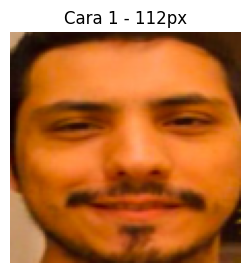

In [8]:
    # Recorte y normalización de rostros

    import cv2
    import numpy as np
    import os
    from PIL import Image
    import matplotlib.pyplot as plt

    # 1. Recuperamos el tamaño objetivo del .env
    target_size = int(os.getenv('FACE_SIZE', 160))

    def normalize_and_align_face(img_rgb, box, landmarks, size=160):
        """
        Realiza la alineación basada en los ojos y el recorte normalizado.
        """
        left_eye = landmarks[0]
        right_eye = landmarks[1]
        
        dY = right_eye[1] - left_eye[1]
        dX = right_eye[0] - left_eye[0]
        angle = np.degrees(np.arctan2(dY, dX))
        
        eye_center = (
            float((left_eye[0] + right_eye[0]) / 2),
            float((left_eye[1] + right_eye[1]) / 2)
        )
        
        M = cv2.getRotationMatrix2D(eye_center, angle, scale=1.0)
        
        h, w = img_rgb.shape[:2]
        aligned_img = cv2.warpAffine(img_rgb, M, (w, h), flags=cv2.INTER_CUBIC)
        
        x1, y1, x2, y2 = map(int, box)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        
        face_crop = aligned_img[y1:y2, x1:x2]
        face_final = cv2.resize(face_crop, (size, size), interpolation=cv2.INTER_AREA)
        
        return face_final

    # --- EJECUCIÓN ---

    # IMPORTANTE: Definimos img_array convirtiendo la 'img' de la celda anterior
    img_array = np.array(img) 

    if boxes is not None:
        print(f"Normalizando {len(boxes)} caras a {target_size}x{target_size}px...")
        
        for i, (box, landmark) in enumerate(zip(boxes, landmarks)):
            # Ahora img_array ya existe en esta celda
            face_normalized = normalize_and_align_face(img_array, box, landmark, size=target_size)
            
            plt.figure(figsize=(3, 3))
            plt.imshow(face_normalized)
            plt.title(f"Cara {i+1} - {target_size}px")
            plt.axis('off')
            plt.show()
            
            # Guardado opcional
            output_dir = os.path.join(os.getenv('OUTPUT_PATH', 'output'), 'normalized_faces')
            os.makedirs(output_dir, exist_ok=True)
            cv2.imwrite(os.path.join(output_dir, f"face_{i}.jpg"), cv2.cvtColor(face_normalized, cv2.COLOR_RGB2BGR))
    else:
        print("No hay caras para normalizar.")

In [5]:
# Carga de modelo

from facenet_pytorch import InceptionResnetV1
import torch

# 1. Cargamos el modelo pre-entrenado
# Usamos 'vggface2' porque es el más robusto para rostros generales
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

In [9]:
# Embeddings

from facenet_pytorch import InceptionResnetV1
import torch

def get_embedding(face_img):
    """
    Recibe la imagen de 160x160 y devuelve el vector de 512 d.
    """
    # El modelo espera un tensor (C, H, W) y normalización de color
    # Convertimos de numpy/PIL a tensor y normalizamos de [0, 255] a [-1, 1]
    face_tensor = torch.tensor(face_img).permute(2, 0, 1).float().to(device)
    face_tensor = (face_tensor - 127.5) / 128.0 
    
    # Añadimos la dimensión del batch: (1, 3, 160, 160)
    face_tensor = face_tensor.unsqueeze(0)
    
    # Generamos el embedding sin calcular gradientes (más rápido)
    with torch.no_grad():
        embedding = resnet(face_tensor)
    
    return embedding.cpu().numpy().flatten()

# --- EJECUCIÓN ---
# Suponiendo que 'face_normalized' es el resultado de tu celda anterior
if 'face_normalized' in locals():
    vector = get_embedding(face_normalized)
    print(f"Embedding generado con éxito. Tamaño del vector: {vector.shape}")
    print(f"Primeros 5 valores: {vector[:5]}")

Embedding generado con éxito. Tamaño del vector: (512,)
Primeros 5 valores: [ 0.02932002 -0.02714488 -0.01666988  0.07775798  0.04965211]


Procesando fotos de Julio...


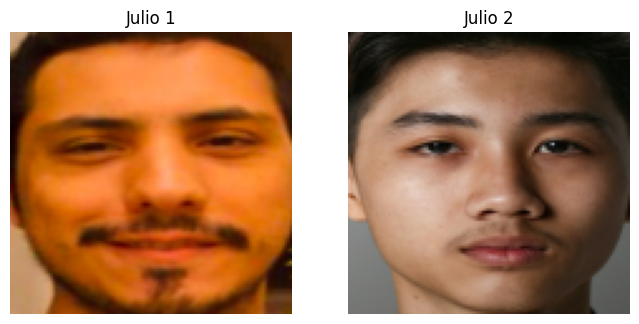

Distancia Euclídea: 1.1713
RESULTADO: No parecen ser la misma persona ❌


In [ ]:
# Prueba de verificación

import os
from scipy.spatial.distance import euclidean

# 1. Definir rutas de las fotos
data_dir = os.getenv('DATA_PATH', 'data')
path_1 = os.path.join(data_dir, 'test_images', 'julio_1.jpg')
path_2 = os.path.join(data_dir, 'test_images', 'frontal.jpg')

def pipeline_completo(ruta_imagen):
    """Encapsula detección, normalización y embedding."""
    img = Image.open(ruta_imagen).convert('RGB')
    
    # Detección
    boxes, probs, landmarks = detector.detect(img, landmarks=True)
    
    if boxes is not None and probs[0] > det_threshold:
        # Tomamos la cara con mayor probabilidad (la primera)
        img_array = np.array(img)
        # Usamos tu función de normalización (160px)
        face_norm = normalize_and_align_face(img_array, boxes[0], landmarks[0], size=target_size)
        # Usamos tu función de embedding
        embedding = get_embedding(face_norm)
        return face_norm, embedding
    else:
        return None, None

# --- EJECUCIÓN Y COMPARACIÓN ---

print("Procesando fotos de Julio...")
face_1, emb_1 = pipeline_completo(path_1)
face_2, emb_2 = pipeline_completo(path_2)

if emb_1 is not None and emb_2 is not None:
    # Calcular Distancia Euclídea
    distancia = euclidean(emb_1, emb_2)
    
    # Umbral recomendado para InceptionResnetV1 (vggface2)[cite: 1]
    umbral = 0.8 
    
    # Visualización
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(face_1); ax[0].set_title("Julio 1"); ax[0].axis('off')
    ax[1].imshow(face_2); ax[1].set_title("Julio 2"); ax[1].axis('off')
    plt.show()
    
    print(f"Distancia Euclídea: {distancia:.4f}")
    
    if distancia < umbral:
        print("RESULTADO: Es la misma persona ✅")
    else:
        print("RESULTADO: No parecen ser la misma persona ❌")
else:
    print("Error: No se pudo detectar un rostro en una de las imágenes.")